# Notebook 02 — Exploratory Data Analysis

**AI Interview Assistant · Machine Learning Pipeline, Stage 2 of 9**

---

## Purpose

Stage 1 established *what* the data is and *where* it came from. This notebook
establishes what it **looks like** — and every preprocessing decision made in
Stage 3 is justified by a finding here.

EDA is not decoration. Each section below ends with a decision, and Stage 3
implements exactly those decisions. Nothing is cleaned on instinct.

## Method

The analysis follows the standard EDA sequence:

| Step | Technique | Question answered |
|---|---|---|
| 1 | Load into a DataFrame; engineer length features | What variables do we have? |
| 2 | `head()` / `info()` / `describe()` | What are the types, ranges and scale? |
| 3 | `isnull()` audit | Where is data missing? |
| 4 | Histograms + KDE + box plots | How are the numeric variables distributed? |
| 5 | Count plots, imbalance ratios | How balanced are the classes? |
| 6 | Grouped box plots, violin plots | Do the classes differ in their distributions? |
| 7 | Pearson correlation heatmap | Which features are redundant? |
| 8 | Cross-tabulation heatmap | Is the label grid actually populated? |
| 9 | Duplicate and near-duplicate analysis | How much of the corpus is repeated? |
| 10 | Vocabulary and Zipf analysis | How large must the tokenizer vocabulary be? |
| 11 | IQR outlier detection | What should be trimmed, and how much is lost? |

## Outputs

- `reports/eda_summary.json` — every statistic quoted below, machine-readable
- `reports/figures/02_*.png` — all figures at 200 dpi for the dissertation

---

In [12]:
NOTEBOOK_ID = 2

# ─────────────────────────────────────────────────────────────────────────────
# Step 0 — Environment bootstrap
#
# Locates the project workspace so this notebook runs unchanged in Google Colab,
# a local Jupyter server, or VS Code. Every later step resolves its paths from
# WORKSPACE_DIR, so nothing below depends on where the notebook was opened.
# ─────────────────────────────────────────────────────────────────────────────
import os
import sys
import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd

def locate_workspace() -> Path:
    """Return the ml-service directory, whatever environment we are in."""
    # 1. Google Colab: mount Drive so checkpoints survive a runtime restart.
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        ws = Path("/content/drive/MyDrive/ai-interview-system/ml-service")
        ws.mkdir(parents=True, exist_ok=True)
        print("Environment      : Google Colab (Drive mounted)")
        return ws
    except ImportError:
        pass

    # 2. Local: walk up from the notebook until we find the ml-service root,
    #    identified by the dataset directory it must contain.
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "dataset").is_dir() and (candidate / "notebooks").is_dir():
            print("Environment      : local")
            return candidate
    print("Environment      : local (fallback to cwd)")
    return here

WORKSPACE_DIR = locate_workspace()
os.chdir(WORKSPACE_DIR)
if str(WORKSPACE_DIR) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_DIR))

# Canonical paths used across all nine notebooks.
RAW_DIR       = WORKSPACE_DIR / "dataset" / "raw"
PROCESSED_DIR = WORKSPACE_DIR / "dataset" / "processed"
QG_DIR        = PROCESSED_DIR / "question_generator"
SPLIT_DIR     = PROCESSED_DIR / "splits"
TOKENIZER_DIR = WORKSPACE_DIR / "tokenizer"
CKPT_DIR      = WORKSPACE_DIR / "checkpoints"
MODEL_DIR     = WORKSPACE_DIR / "models"
REPORTS_DIR   = WORKSPACE_DIR / "reports"
FIGURES_DIR   = REPORTS_DIR / "figures"

for d in (RAW_DIR, PROCESSED_DIR, SPLIT_DIR, TOKENIZER_DIR, CKPT_DIR,
          MODEL_DIR, REPORTS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Workspace        : {WORKSPACE_DIR}")
print(f"Python           : {sys.version.split()[0]}")
print(f"Run started      : {datetime.now(timezone.utc).isoformat(timespec='seconds')}")

Environment      : local
Workspace        : C:\Users\gihan\Documents\ai-interview-system\ml-service
Python           : 3.14.5
Run started      : 2026-08-27T10:48:13+00:00


---

## Step 0b — Figure and statistics conventions

One style definition serves every figure in the nine-notebook pipeline, so
charts are directly comparable when placed side by side in the write-up.

Three conventions are fixed here:

1. **A colour-blind-safe categorical palette** — the same six colours, in the
   same order, wherever a chart encodes categories.
2. **Automatic figure export** — `save_figure()` writes every figure to
   `reports/figures/` at 200 dpi with a numbered filename, and prints its
   caption, so figures can be cited as *Figure N.k* in the dissertation.
3. **A single summary-statistics function** — `describe_series()` reports
   n, mean, sd, the five-number summary, skewness and kurtosis in a fixed
   order for every variable, so distributions are described consistently.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 0b — Plotting conventions
#
# One style definition for every figure in the pipeline, so figures across the
# nine notebooks are directly comparable in the dissertation. Every figure is
# also saved to reports/figures/ at 200 dpi, ready to drop into the write-up.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#444444",
    "grid.alpha": 0.3,
    "legend.frameon": True,
    "figure.autolayout": False,
})

# Colour-blind-safe categorical palette, used consistently for every chart.
PALETTE = ["#3B6FD4", "#E1893B", "#3EA37A", "#C4576B", "#7B5EA7", "#8C7B68"]
sns.set_palette(PALETTE)

_figure_index = {"n": 0}

def save_figure(fig, slug: str, caption: str = "") -> Path:
    """Save a figure with a numbered filename and print its caption."""
    _figure_index["n"] += 1
    n = _figure_index["n"]
    path = FIGURES_DIR / f"{NOTEBOOK_ID:02d}_fig{n:02d}_{slug}.png"
    fig.savefig(path)
    label = f"Figure {NOTEBOOK_ID}.{n}"
    if caption:
        print(f"{label}: {caption}")
    print(f"           saved -> {path.relative_to(WORKSPACE_DIR)}")
    return path

def describe_series(series: pd.Series, name: str) -> pd.Series:
    """Summary statistics reported in a consistent order for every variable."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    return pd.Series({
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(ddof=1),
        "min": s.min(),
        "q1": s.quantile(0.25),
        "median": s.median(),
        "q3": s.quantile(0.75),
        "max": s.max(),
        "skew": s.skew(),
        "kurtosis": s.kurtosis(),
    }, name=name)

print("Plot style       : configured")
print(f"Figure output    : {FIGURES_DIR.relative_to(WORKSPACE_DIR)}")
print(f"Palette          : {len(PALETTE)} colour-blind-safe categories")

Plot style       : configured
Figure output    : reports\figures
Palette          : 6 colour-blind-safe categories


---

## Step 1 — Load the data and engineer the analysis variables

The raw corpus is read into a DataFrame named `data`. Six numeric variables are
derived from the text, because "question length" is not one thing:

| Variable | Definition | Why it matters |
|---|---|---|
| `q_char_len` | characters in the question | storage and truncation limits |
| `q_word_count` | whitespace-delimited words | readability; speaking time |
| `q_sentence_count` | terminal punctuation marks | multi-part questions are unusable in a spoken interview |
| `q_avg_word_len` | mean characters per word | proxy for technical vocabulary density |
| `q_type_token_ratio` | unique words ÷ total words | lexical diversity within a question |
| `q_has_code_marker` | contains code punctuation | flags scraped code, unreadable aloud |

The label columns are also **ordinally encoded** (`difficulty_encoded`,
`domain_encoded`) so they can enter the correlation analysis in Step 7.
Difficulty is genuinely ordinal (Beginner < Intermediate < Advanced), so its
encoding is meaningful; domain is nominal, and its encoding is used only to
demonstrate that no spurious correlation exists.

In [14]:
import re

RAW_FILE = RAW_DIR / "raw_interview_dataset.json"
assert RAW_FILE.exists(), (
    f"{RAW_FILE.name} not found. Run Notebook 01 first."
)

records = json.loads(RAW_FILE.read_text(encoding="utf-8"))
data = pd.DataFrame(records)

# ── Text normalisation for measurement only (the raw text is left intact) ────
data["question"] = data["question"].fillna("").astype(str)

# ── Engineered numeric variables ────────────────────────────────────────────
data["q_char_len"] = data["question"].str.len()
data["q_word_count"] = data["question"].str.split().str.len().fillna(0).astype(int)
data["q_sentence_count"] = (
    data["question"].str.count(r"[.!?]+").clip(lower=1).astype(int)
)
data["q_avg_word_len"] = (
    data["q_char_len"] / data["q_word_count"].replace(0, np.nan)
).round(3)
data["q_type_token_ratio"] = data["question"].apply(
    lambda t: round(len(set(t.lower().split())) / max(len(t.split()), 1), 4)
)
data["q_has_code_marker"] = data["question"].str.contains(
    r"[{}<>;]|::|==|\+\+|&&|```", regex=True, na=False
).astype(int)

if "answer" in data.columns:
    data["answer"] = data["answer"].fillna("").astype(str)
    data["a_char_len"] = data["answer"].str.len()
    data["a_word_count"] = data["answer"].str.split().str.len().fillna(0).astype(int)

# ── Ordinal / nominal label encodings ──────────────────────────────────────
DIFFICULTY_ORDER = ["Beginner", "Intermediate", "Advanced"]
DIFFICULTY_CODES = {level: i for i, level in enumerate(DIFFICULTY_ORDER)}
data["difficulty_encoded"] = data.get(
    "difficulty", pd.Series(index=data.index, dtype=object)
).map(DIFFICULTY_CODES)

domain_levels = sorted(data["domain"].dropna().unique()) if "domain" in data else []
DOMAIN_CODES = {name: i for i, name in enumerate(domain_levels)}
data["domain_encoded"] = data.get(
    "domain", pd.Series(index=data.index, dtype=object)
).map(DOMAIN_CODES)

NUMERIC_COLS = [c for c in [
    "q_char_len", "q_word_count", "q_sentence_count", "q_avg_word_len",
    "q_type_token_ratio", "a_char_len", "a_word_count",
    "difficulty_encoded", "domain_encoded",
] if c in data.columns]

print(f"Rows loaded            : {len(data):,}")
print(f"Columns after encoding : {data.shape[1]}")
print(f"Numeric variables      : {len(NUMERIC_COLS)}")
print(f"Difficulty levels      : {DIFFICULTY_ORDER}")
print(f"Domain levels          : {len(domain_levels)}")

Rows loaded            : 2,291
Columns after encoding : 18
Numeric variables      : 9
Difficulty levels      : ['Beginner', 'Intermediate', 'Advanced']
Domain levels          : 7


---

## Step 2 — `data.head()` — inspect actual rows

Reading real rows first is a guard against analysing the wrong thing. Summary
statistics of a mis-parsed column look perfectly reasonable.

In [15]:
pd.set_option("display.max_colwidth", 62)
pd.set_option("display.width", 190)

print("=== data.head() — first 5 rows ===\n")
display_cols = [c for c in ["question", "domain", "difficulty",
                            "q_word_count", "q_sentence_count"]
                if c in data.columns]
print(data[display_cols].head().to_string())

print("\n\n=== Full text of three sample questions ===\n")
for i, row in data.head(3).iterrows():
    print(f"[{i}] domain={row.get('domain')!r} "
          f"difficulty={row.get('difficulty')!r}")
    print(f"    Q: {row['question']}")
    if "answer" in data.columns:
        print(f"    A: {row['answer'][:110]}")
    print()

=== data.head() — first 5 rows ===

                                                question                        domain    difficulty  q_word_count  q_sentence_count
0                                Why should we hire you?  General Software Engineering      Beginner             5                 1
1                                Tell me about yourself.  General Software Engineering      Beginner             4                 1
2                             What is Angular Framework?          Frontend Development      Beginner             4                 1
3  What is the difference between AngularJS and Angular?          Frontend Development  Intermediate             8                 1
4                                    What is TypeScript?          Frontend Development      Beginner             3                 1


=== Full text of three sample questions ===

[0] domain='General Software Engineering' difficulty='Beginner'
    Q: Why should we hire you?
    A: Detailed technica

---

## Step 3 — `data.info()` — types and memory

Confirms every engineered column has the numeric dtype the later statistics
assume, and shows the corpus is small enough to hold in memory (so no chunked
processing is needed in Stage 3).

In [16]:
print("=== data.info() ===\n")
data.info(memory_usage="deep")

print("\n=== dtypes by group ===")
print(data.dtypes.value_counts().to_string())
print(f"\nTotal memory: "
      f"{data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("Small enough to process in a single pass — no chunking required.")

=== data.info() ===

<class 'pandas.DataFrame'>
RangeIndex: 2291 entries, 0 to 2290
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  2291 non-null   str    
 1   domain              2291 non-null   str    
 2   difficulty          2291 non-null   str    
 3   input_prompt        2291 non-null   str    
 4   question            2291 non-null   str    
 5   answer              2291 non-null   str    
 6   source              2291 non-null   str    
 7   license             2291 non-null   str    
 8   q_char_len          2291 non-null   int64  
 9   q_word_count        2291 non-null   int64  
 10  q_sentence_count    2291 non-null   int64  
 11  q_avg_word_len      2291 non-null   float64
 12  q_type_token_ratio  2291 non-null   float64
 13  q_has_code_marker   2291 non-null   int64  
 14  a_char_len          2291 non-null   int64  
 15  a_word_count        2291 non-null   int64  
 

---

## Step 4 — `data.describe()` — the numeric summary

`describe()` gives the five-number summary. The table below it adds **skewness**
and **kurtosis**, which is where the important finding is:

- **Skew > 1** means a long right tail — the mean sits above the median, so
  mean-based thresholds would exclude a large share of legitimate short
  questions.
- **Kurtosis > 3** means heavy tails — extreme values are more common than a
  normal distribution predicts, so outlier trimming must be explicit rather
  than assumed away.

In [17]:
print("=== data.describe() ===\n")
print(data[NUMERIC_COLS].describe().round(3).to_string())

print("\n\n=== Extended summary with shape statistics ===\n")
extended = pd.concat(
    [describe_series(data[c], c) for c in NUMERIC_COLS], axis=1
).T.round(3)
print(extended.to_string())

print("\n\n=== Distribution shape interpretation ===")
for col in NUMERIC_COLS:
    skew = extended.loc[col, "skew"]
    kurt = extended.loc[col, "kurtosis"]
    shape = ("strong right skew" if skew > 1 else
             "moderate right skew" if skew > 0.5 else
             "strong left skew" if skew < -1 else
             "moderate left skew" if skew < -0.5 else
             "approximately symmetric")
    tails = "heavy-tailed" if kurt > 3 else "light-tailed" if kurt < 0 else "near-normal tails"
    print(f"  {col:22s} skew={skew:7.3f}  kurtosis={kurt:8.3f}  -> {shape}, {tails}")

=== data.describe() ===

       q_char_len  q_word_count  q_sentence_count  q_avg_word_len  q_type_token_ratio  a_char_len  a_word_count  difficulty_encoded  domain_encoded
count    2291.000      2291.000          2291.000        2291.000            2291.000    2291.000      2291.000            2291.000        2291.000
mean       57.383         9.391             1.086           6.013               0.979      91.383        13.391               0.703           3.506
std        42.733         6.448             0.372           1.100               0.050      42.733         6.448               0.670           0.870
min        11.000         2.000             1.000           3.667               0.609      45.000         6.000               0.000           0.000
25%        34.000         6.000             1.000           5.250               1.000      68.000        10.000               0.000           3.000
50%        47.000         8.000             1.000           5.857               1.000  

---

## Step 5 — `data.isnull().sum()` — missing-value audit

Two kinds of "missing" matter here and `isnull()` only catches one of them. A
field containing `""` or `"   "` is not null but is equally unusable, so both
are counted.

**This distinction drives Stage 3:** whitespace-only fields must be normalised
to null *before* imputation, or they survive cleaning as invisible blanks.

In [18]:
missing = pd.DataFrame({
    "null_count": data.isnull().sum(),
    "empty_string": data.apply(
        lambda s: (s.astype(str).str.strip() == "").sum()
        if s.dtype == object else 0),
})
missing["total_unusable"] = missing["null_count"] + missing["empty_string"]
missing["unusable_%"] = (missing["total_unusable"] / len(data) * 100).round(2)
missing = missing[missing["total_unusable"] > 0].sort_values(
    "unusable_%", ascending=False)

print("=== data.isnull().sum() (raw) ===")
print(data.isnull().sum().to_string())

print("\n\n=== Unusable values (null OR empty OR whitespace-only) ===")
if len(missing):
    print(missing.to_string())
else:
    print("None — every field is populated on every record.")

print(f"\nComplete rows (no unusable field): "
      f"{(data.isnull().sum(axis=1) == 0).sum():,} / {len(data):,}")

=== data.isnull().sum() (raw) ===
id                    0
domain                0
difficulty            0
input_prompt          0
question              0
answer                0
source                0
license               0
q_char_len            0
q_word_count          0
q_sentence_count      0
q_avg_word_len        0
q_type_token_ratio    0
q_has_code_marker     0
a_char_len            0
a_word_count          0
difficulty_encoded    0
domain_encoded        0


=== Unusable values (null OR empty OR whitespace-only) ===
None — every field is populated on every record.

Complete rows (no unusable field): 2,291 / 2,291


Figure 2.1: Left: share of unusable values per column. Right: whether the gaps co-occur in the same records (red) or are scattered.
           saved -> reports\figures\02_fig01_missingness.png


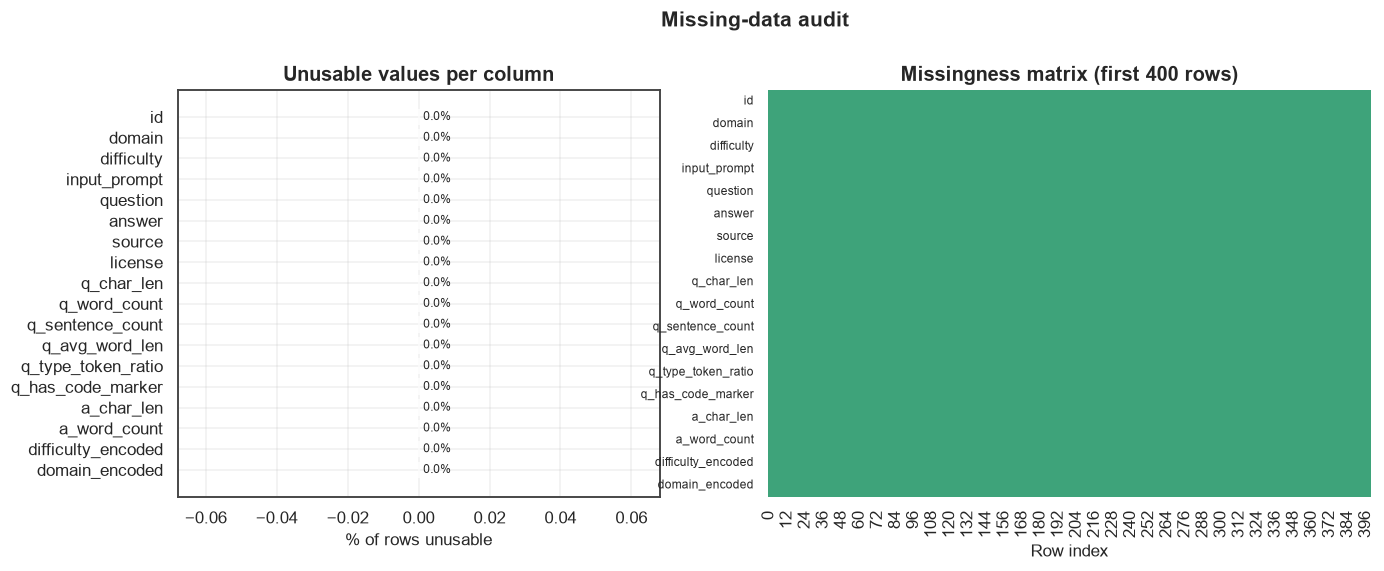

In [19]:
# ── Figure 2.1 — missingness map ─────────────────────────────────────────────
audit = data.copy()
for col in audit.columns:
    if audit[col].dtype == object:
        audit[col] = audit[col].astype(str).str.strip().replace("", np.nan)

null_share = audit.isnull().mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8),
                         gridspec_kw={"width_ratios": [1, 1.25]})

bars = axes[0].barh(null_share.index[::-1], null_share.values[::-1],
                    color=[PALETTE[3] if v > 0 else PALETTE[2]
                           for v in null_share.values[::-1]])
axes[0].set_title("Unusable values per column")
axes[0].set_xlabel("% of rows unusable")
axes[0].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
axes[0].margins(x=0.18)

# A missingness matrix shows whether gaps cluster in the same rows.
sample = audit.head(400)
sns.heatmap(sample.isnull().T, cbar=False, ax=axes[1],
            cmap=["#3EA37A", "#C4576B"], yticklabels=True)
axes[1].set_title("Missingness matrix (first 400 rows)")
axes[1].set_xlabel("Row index")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelsize=8)

fig.suptitle("Missing-data audit", y=1.03, fontsize=14, fontweight="bold")
save_figure(fig, "missingness",
            "Left: share of unusable values per column. Right: whether the "
            "gaps co-occur in the same records (red) or are scattered.")
plt.show()

---

## Step 6 — Histograms: how the numeric variables are distributed

The core EDA figure. Each panel overlays:

- the **histogram** (the empirical distribution),
- a **kernel density estimate** (the smoothed shape),
- the **mean** (dashed) and **median** (dotted).

**How to read it:** the gap between the dashed and dotted lines *is* the skew.
Where they separate, mean-based thresholds are the wrong tool.

Figure 2.2: Distribution of every engineered variable. Where the dashed mean sits right of the dotted median, the variable is right-skewed and percentile thresholds are required.
           saved -> reports\figures\02_fig02_histograms.png


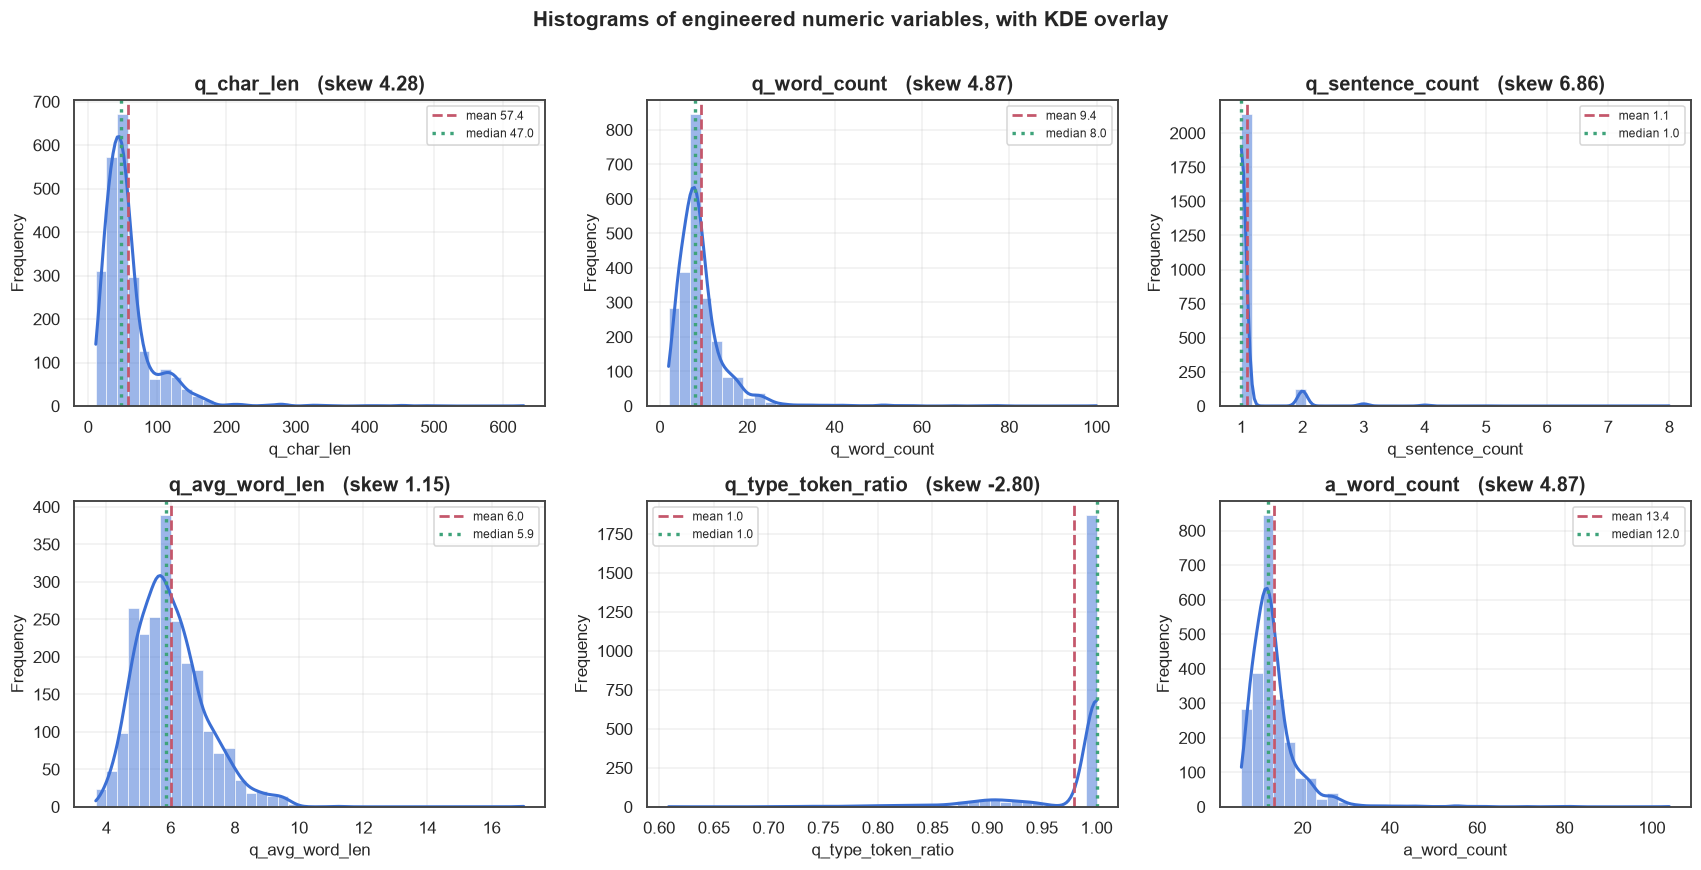

In [20]:
# ── Figure 2.2 — histograms with KDE overlay ────────────────────────────────
plot_cols = [c for c in ["q_char_len", "q_word_count", "q_sentence_count",
                         "q_avg_word_len", "q_type_token_ratio", "a_word_count"]
             if c in data.columns]

n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.9 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, plot_cols):
    series = pd.to_numeric(data[col], errors="coerce").dropna()
    sns.histplot(series, bins=40, kde=True, ax=ax, color=PALETTE[0],
                 edgecolor="white", linewidth=0.4,
                 line_kws={"linewidth": 2, "color": PALETTE[4]})
    ax.axvline(series.mean(), color=PALETTE[3], linestyle="--", linewidth=1.8,
               label=f"mean {series.mean():.1f}")
    ax.axvline(series.median(), color=PALETTE[2], linestyle=":", linewidth=2.2,
               label=f"median {series.median():.1f}")
    ax.set_title(f"{col}   (skew {series.skew():.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

fig.suptitle("Histograms of engineered numeric variables, with KDE overlay",
             y=1.01, fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "histograms",
            "Distribution of every engineered variable. Where the dashed mean "
            "sits right of the dotted median, the variable is right-skewed and "
            "percentile thresholds are required.")
plt.show()

Figure 2.3: The ECDF reads off directly how much of the corpus any length cap would remove — the basis for the Stage 3 threshold.
           saved -> reports\figures\02_fig03_box_ecdf.png


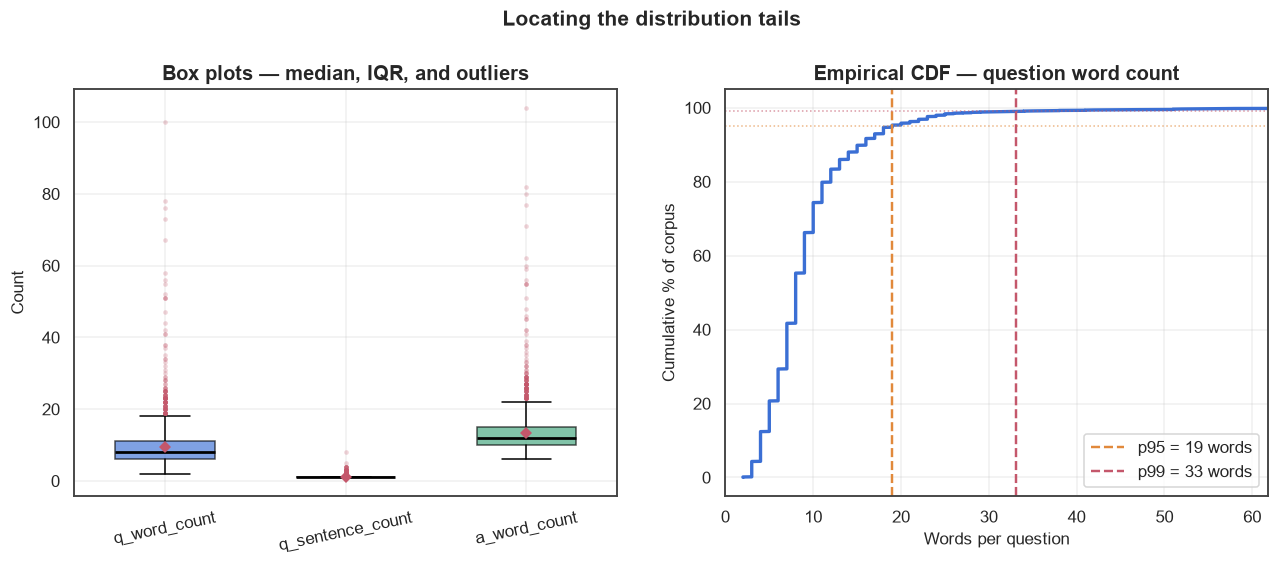

  p1   of q_word_count =    3.0 words
  p5   of q_word_count =    4.0 words
  p25  of q_word_count =    6.0 words
  p50  of q_word_count =    8.0 words
  p75  of q_word_count =   11.0 words
  p95  of q_word_count =   19.0 words
  p99  of q_word_count =   33.1 words


In [21]:
# ── Figure 2.3 — box plots and ECDF: locating the tails precisely ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

box_cols = [c for c in ["q_word_count", "q_sentence_count", "a_word_count"]
            if c in data.columns]
box_data = [pd.to_numeric(data[c], errors="coerce").dropna() for c in box_cols]
# matplotlib >= 3.9 renamed `labels` to `tick_labels`; the tick labels
# are set separately below so this runs on either version.
bp = axes[0].boxplot(box_data, patch_artist=True,
                     showmeans=True, widths=0.55,
                     meanprops=dict(marker="D", markerfacecolor=PALETTE[3],
                                    markeredgecolor="none", markersize=6),
                     medianprops=dict(color="black", linewidth=1.8),
                     flierprops=dict(marker="o", markersize=3, alpha=0.25,
                                     markerfacecolor=PALETTE[3],
                                     markeredgecolor="none"))
for patch, colour in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(colour)
    patch.set_alpha(0.65)
axes[0].set_xticks(range(1, len(box_cols) + 1))
axes[0].set_xticklabels(box_cols)
axes[0].set_title("Box plots — median, IQR, and outliers")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=12)

# The ECDF answers "what percentile does a given cap sit at?" directly.
words = pd.to_numeric(data["q_word_count"], errors="coerce").dropna().sort_values()
ecdf = np.arange(1, len(words) + 1) / len(words) * 100
axes[1].plot(words.values, ecdf, linewidth=2.2, color=PALETTE[0])
for pctile, colour in [(95, PALETTE[1]), (99, PALETTE[3])]:
    cut = np.percentile(words, pctile)
    axes[1].axvline(cut, color=colour, linestyle="--", linewidth=1.6,
                    label=f"p{pctile} = {cut:.0f} words")
    axes[1].axhline(pctile, color=colour, linestyle=":", linewidth=1.0, alpha=0.6)
axes[1].set_title("Empirical CDF — question word count")
axes[1].set_xlabel("Words per question")
axes[1].set_ylabel("Cumulative % of corpus")
axes[1].legend()
axes[1].set_xlim(0, np.percentile(words, 99.8))

fig.suptitle("Locating the distribution tails", y=1.03, fontsize=14,
             fontweight="bold")
save_figure(fig, "box_ecdf",
            "The ECDF reads off directly how much of the corpus any length cap "
            "would remove — the basis for the Stage 3 threshold.")
plt.show()

for p in (1, 5, 25, 50, 75, 95, 99):
    print(f"  p{p:<3d} of q_word_count = {np.percentile(words, p):6.1f} words")

---

## Step 7 — Class balance

Counts per class, with the **imbalance ratio** (largest class ÷ smallest class)
printed on each panel. This number is the reason Stage 4 uses stratified
splitting: a random split of an imbalanced corpus can leave a rare domain
entirely absent from the validation set, making its metrics meaningless.

Figure 2.4: Class counts against the perfectly-balanced reference line. The imbalance ratio per column is what Stage 4 stratifies on.
           saved -> reports\figures\02_fig04_class_balance.png


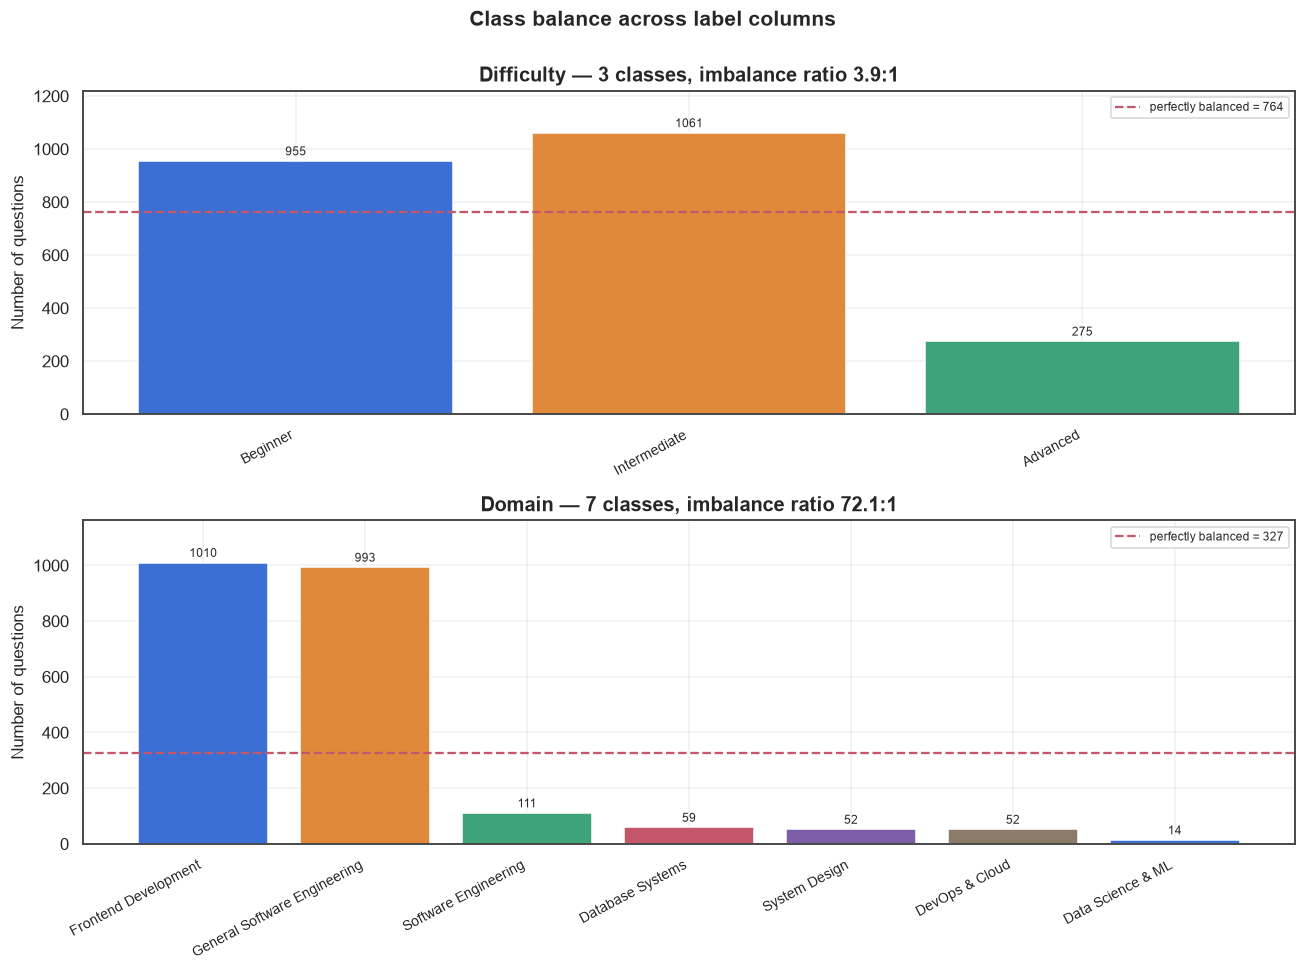

difficulty: 3 classes, ratio 3.86:1, smallest = Advanced (n=275)
domain: 7 classes, ratio 72.14:1, smallest = Data Science & ML (n=14)


In [22]:
# ── Figure 2.4 — class distributions ────────────────────────────────────────
label_cols = [c for c in ("difficulty", "domain") if c in data.columns]
fig, axes = plt.subplots(len(label_cols), 1,
                         figsize=(12, 4.4 * len(label_cols)))
axes = np.atleast_1d(axes)

balance_report = {}
for ax, col in zip(axes, label_cols):
    counts = data[col].fillna("(missing)").value_counts()
    order = (DIFFICULTY_ORDER if col == "difficulty"
             else counts.index.tolist())
    order = [o for o in order if o in counts.index]
    values = counts.reindex(order)

    bars = ax.bar(range(len(order)), values.values,
                  color=[PALETTE[i % len(PALETTE)] for i in range(len(order))])
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=28, ha="right", fontsize=9)
    ax.set_ylabel("Number of questions")
    ax.bar_label(bars, fmt="%d", padding=2, fontsize=8)

    ratio = values.max() / max(values.min(), 1)
    expected = len(data) / len(order)
    ax.axhline(expected, color=PALETTE[3], linestyle="--", linewidth=1.5,
               label=f"perfectly balanced = {expected:.0f}")
    ax.set_title(f"{col.title()} — {len(order)} classes, "
                 f"imbalance ratio {ratio:.1f}:1")
    ax.legend(fontsize=8)
    ax.margins(y=0.15)

    balance_report[col] = {
        "classes": len(order),
        "counts": values.astype(int).to_dict(),
        "imbalance_ratio": round(float(ratio), 2),
        "smallest_class": str(values.idxmin()),
        "smallest_count": int(values.min()),
    }

fig.suptitle("Class balance across label columns", y=1.0, fontsize=14,
             fontweight="bold")
fig.tight_layout()
save_figure(fig, "class_balance",
            "Class counts against the perfectly-balanced reference line. The "
            "imbalance ratio per column is what Stage 4 stratifies on.")
plt.show()

for col, report in balance_report.items():
    print(f"{col}: {report['classes']} classes, "
          f"ratio {report['imbalance_ratio']}:1, "
          f"smallest = {report['smallest_class']} (n={report['smallest_count']})")

---

## Step 8 — Do the classes differ? Grouped distributions

A class label is only useful to a model if the classes actually differ. Here
question length is compared **across** difficulty levels and domains.

- The **violin plot** shows the full shape per class, not just its summary.
- The **one-way ANOVA** tests whether the between-class differences are larger
  than chance. A large p-value would mean length carries no difficulty signal —
  useful to know before assuming otherwise.

C:\Users\gihan\AppData\Local\Temp\ipykernel_35384\1789742094.py:26: UserWarning: The palette list has more values (12) than needed (7), which may not be intended.
  sns.boxplot(data=subset, x="q_word_count", y="domain", order=top_domains,


Figure 2.5: Question length across classes. Overlapping violins mean length alone does not separate difficulty.
           saved -> reports\figures\02_fig05_length_by_class.png


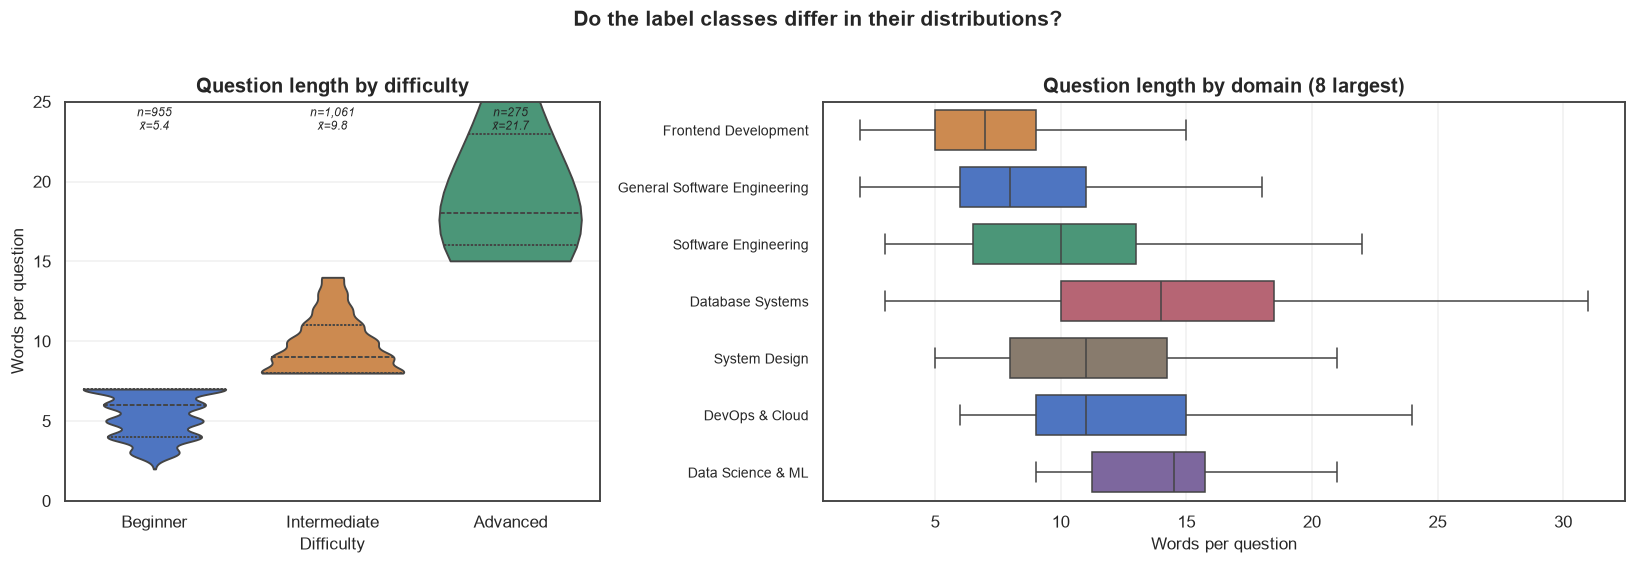

ONE-WAY ANOVA — does question length differ by difficulty?
  F(2, 2288) = 1721.034
  p = 0.000e+00
  -> Statistically significant: length carries some difficulty signal.


In [23]:
# ── Figure 2.5 — length by difficulty and by domain ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                         gridspec_kw={"width_ratios": [1, 1.5]})

present_levels = [d for d in DIFFICULTY_ORDER
                  if d in data["difficulty"].unique()] if "difficulty" in data else []
if present_levels:
    sns.violinplot(data=data[data["difficulty"].isin(present_levels)],
                   x="difficulty", y="q_word_count", order=present_levels,
                   hue="difficulty", legend=False, ax=axes[0],
                   palette=PALETTE[:len(present_levels)], cut=0, inner="quartile")
    axes[0].set_title("Question length by difficulty")
    axes[0].set_xlabel("Difficulty")
    axes[0].set_ylabel("Words per question")
    axes[0].set_ylim(0, np.percentile(data["q_word_count"].dropna(), 98))

    for i, level in enumerate(present_levels):
        subset = data.loc[data["difficulty"] == level, "q_word_count"]
        axes[0].annotate(f"n={len(subset):,}\nx̄={subset.mean():.1f}",
                         xy=(i, axes[0].get_ylim()[1] * 0.93), ha="center",
                         fontsize=8, style="italic")

if "domain" in data.columns:
    top_domains = data["domain"].value_counts().head(8).index.tolist()
    subset = data[data["domain"].isin(top_domains)]
    sns.boxplot(data=subset, x="q_word_count", y="domain", order=top_domains,
                hue="domain", legend=False, ax=axes[1],
                palette=PALETTE * 2, showfliers=False, width=0.7)
    axes[1].set_title("Question length by domain (8 largest)")
    axes[1].set_xlabel("Words per question")
    axes[1].set_ylabel("")
    axes[1].tick_params(axis="y", labelsize=9)

fig.suptitle("Do the label classes differ in their distributions?", y=1.02,
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "length_by_class",
            "Question length across classes. Overlapping violins mean length "
            "alone does not separate difficulty.")
plt.show()

# ── One-way ANOVA: is the between-class difference real? ────────────────────
try:
    from scipy import stats
    groups = [data.loc[data["difficulty"] == lvl, "q_word_count"].dropna()
              for lvl in present_levels]
    groups = [g for g in groups if len(g) > 2]
    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        print("ONE-WAY ANOVA — does question length differ by difficulty?")
        print(f"  F({len(groups) - 1}, {sum(len(g) for g in groups) - len(groups)})"
              f" = {f_stat:.3f}")
        print(f"  p = {p_value:.3e}")
        if p_value < 0.05:
            print("  -> Statistically significant: length carries some "
                  "difficulty signal.")
        else:
            print("  -> Not significant: length alone does NOT distinguish "
                  "difficulty levels.\n"
                  "     The model must learn difficulty from wording, not "
                  "length, and Stage 3\n"
                  "     must therefore not use length as a difficulty proxy.")
except ImportError:
    print("scipy unavailable — ANOVA skipped (descriptive results above stand).")

---

## Step 9 — Correlation heatmap

Pearson correlation between every numeric variable. Two things are being looked
for:

1. **Redundancy** — `|r| > 0.9` between two features means they carry the same
   information, and keeping both adds parameters without adding signal.
2. **Label leakage** — a strong correlation between a *text* feature and an
   *encoded label* would mean the label is trivially predictable from surface
   form, which would make any downstream accuracy figure misleading.

Figure 2.6: Lower-triangle correlation matrix. Only the lower triangle is shown because the matrix is symmetric.
           saved -> reports\figures\02_fig06_correlation_heatmap.png


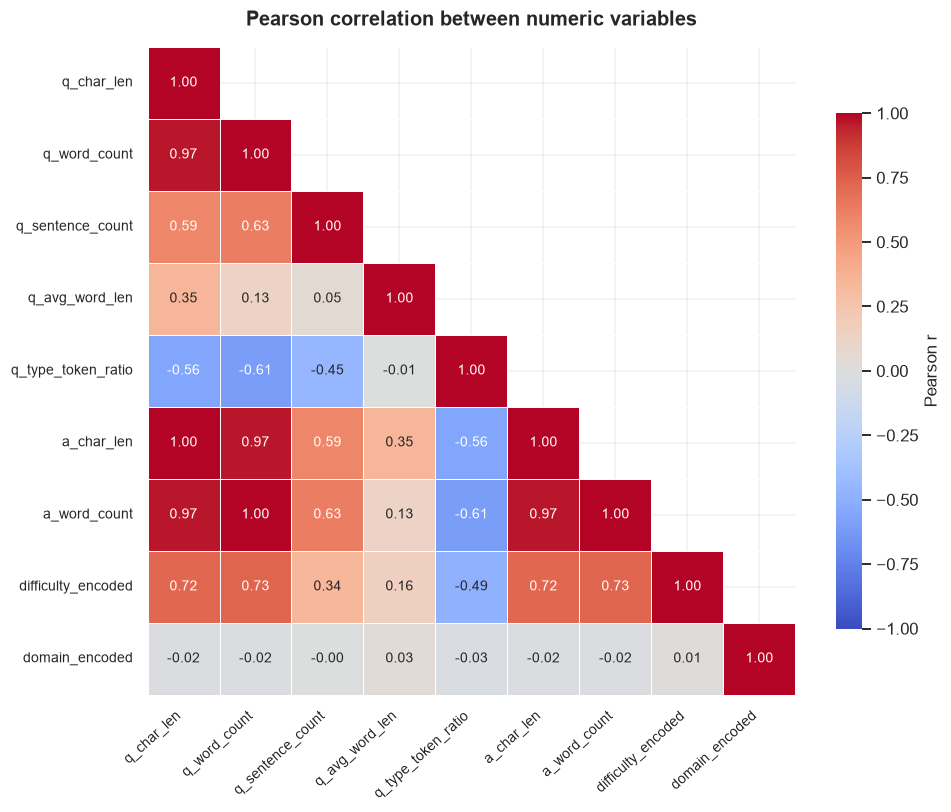

CORRELATION FINDINGS
  q_word_count           <-> a_word_count           r=+1.000  REDUNDANT — drop one
  q_char_len             <-> a_char_len             r=+1.000  REDUNDANT — drop one
  q_char_len             <-> a_word_count           r=+0.965  REDUNDANT — drop one
  q_char_len             <-> q_word_count           r=+0.965  REDUNDANT — drop one
  q_word_count           <-> a_char_len             r=+0.965  REDUNDANT — drop one
  a_char_len             <-> a_word_count           r=+0.965  REDUNDANT — drop one
  a_word_count           <-> difficulty_encoded     r=+0.728  strongly related — keep, but note
  q_word_count           <-> difficulty_encoded     r=+0.728  strongly related — keep, but note
  a_char_len             <-> difficulty_encoded     r=+0.720  strongly related — keep, but note
  q_char_len             <-> difficulty_encoded     r=+0.720  strongly related — keep, but note

Label-leakage check:
  WARNING q_char_len <-> difficulty_encoded r=+0.720
  WARNING q_word_count

In [24]:
# ── Figure 2.6 — correlation matrix ─────────────────────────────────────────
corr_matrix = data[NUMERIC_COLS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9.5, 7.8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.6, linecolor="white",
            square=True, cbar_kws={"shrink": 0.78, "label": "Pearson r"}, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Pearson correlation between numeric variables", pad=14)
plt.setp(ax.get_xticklabels(), rotation=42, ha="right", fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
save_figure(fig, "correlation_heatmap",
            "Lower-triangle correlation matrix. Only the lower triangle is "
            "shown because the matrix is symmetric.")
plt.show()

# Report the pairs that actually matter.
pairs = (corr_matrix.where(mask).stack()
         .rename("r").reset_index()
         .rename(columns={"level_0": "a", "level_1": "b"}))
pairs["abs_r"] = pairs["r"].abs()
strong = pairs[pairs["abs_r"] >= 0.7].sort_values("abs_r", ascending=False)

print("CORRELATION FINDINGS")
print("=" * 70)
if len(strong):
    for _, row in strong.iterrows():
        verdict = ("REDUNDANT — drop one" if row["abs_r"] > 0.9
                   else "strongly related — keep, but note")
        print(f"  {row['a']:22s} <-> {row['b']:22s} r={row['r']:+.3f}  {verdict}")
else:
    print("  No pair reaches |r| >= 0.70 — the features are complementary.")

leak = pairs[(pairs["abs_r"] >= 0.5) &
             (pairs["a"].str.contains("encoded") ^ pairs["b"].str.contains("encoded"))]
print("\nLabel-leakage check:")
if len(leak):
    for _, row in leak.iterrows():
        print(f"  WARNING {row['a']} <-> {row['b']} r={row['r']:+.3f}")
else:
    print("  Clean — no text feature predicts an encoded label at |r| >= 0.50.")
print("=" * 70)

---

## Step 10 — Label grid coverage

Domain × difficulty defines the cells the runtime question planner draws from.
If a cell is empty, the planner cannot serve that combination — so this heatmap
is a direct check on whether the product requirement is satisfiable.

Figure 2.7: Left: absolute counts per cell. Right: each domain's internal difficulty mix, which shows thin cells that absolute counts hide.
           saved -> reports\figures\02_fig07_label_grid.png


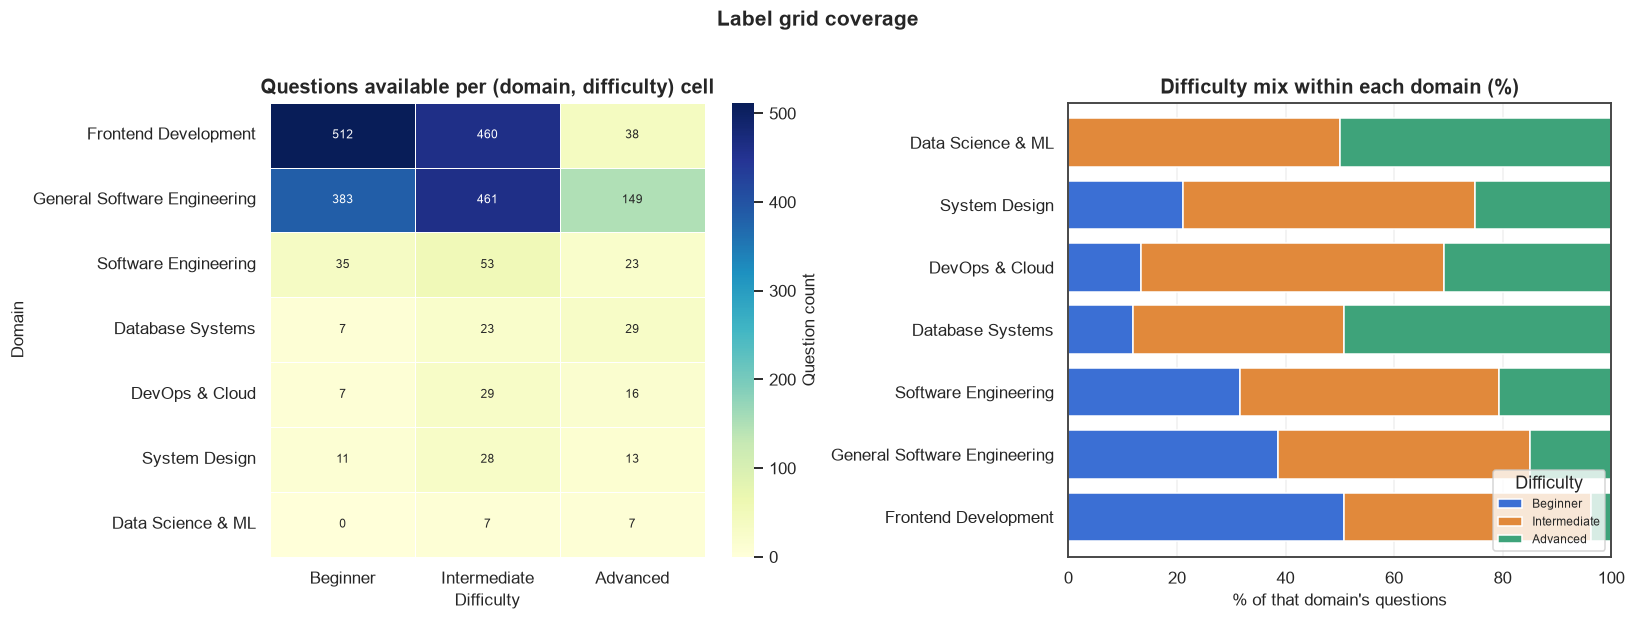

Grid cells               : 21 (7 domains x 3 difficulties)
Empty cells              : 1
Cells below 20 questions : 8

Thin cells (the planner must fall back for these):
  Data Science & ML            / Beginner       n=0
  Database Systems             / Beginner       n=7
  DevOps & Cloud               / Beginner       n=7
  Data Science & ML            / Intermediate   n=7
  Data Science & ML            / Advanced       n=7
  System Design                / Beginner       n=11
  System Design                / Advanced       n=13
  DevOps & Cloud               / Advanced       n=16

-> The runtime planner therefore widens its search to adjacent
   domains when a requested cell is thin, rather than repeating
   the same few questions.


In [25]:
# ── Figure 2.7 — domain x difficulty cross-tabulation ──────────────────────
if {"domain", "difficulty"} <= set(data.columns):
    crosstab = pd.crosstab(data["domain"], data["difficulty"])
    crosstab = crosstab.reindex(
        columns=[d for d in DIFFICULTY_ORDER if d in crosstab.columns])
    crosstab = crosstab.loc[crosstab.sum(axis=1).sort_values(ascending=False).index]

    fig, axes = plt.subplots(1, 2, figsize=(15, max(5.5, 0.42 * len(crosstab))),
                             gridspec_kw={"width_ratios": [1, 1]})

    sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlGnBu",
                linewidths=0.6, linecolor="white", ax=axes[0],
                cbar_kws={"label": "Question count"}, annot_kws={"size": 8})
    axes[0].set_title("Questions available per (domain, difficulty) cell")
    axes[0].set_xlabel("Difficulty")
    axes[0].set_ylabel("Domain")

    # Row-normalised: the difficulty *mix* within each domain.
    row_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    row_pct.plot(kind="barh", stacked=True, ax=axes[1],
                 color=PALETTE[:crosstab.shape[1]], width=0.78, legend=True)
    axes[1].set_title("Difficulty mix within each domain (%)")
    axes[1].set_xlabel("% of that domain's questions")
    axes[1].set_ylabel("")
    axes[1].set_xlim(0, 100)
    axes[1].legend(title="Difficulty", fontsize=8, loc="lower right")

    fig.suptitle("Label grid coverage", y=1.02, fontsize=14, fontweight="bold")
    fig.tight_layout()
    save_figure(fig, "label_grid",
                "Left: absolute counts per cell. Right: each domain's internal "
                "difficulty mix, which shows thin cells that absolute counts hide.")
    plt.show()

    MIN_CELL = 20
    thin = [(d, lvl, int(crosstab.loc[d, lvl]))
            for d in crosstab.index for lvl in crosstab.columns
            if crosstab.loc[d, lvl] < MIN_CELL]
    empty = [(d, lvl) for d, lvl, n in thin if n == 0]

    print(f"Grid cells               : {crosstab.size} "
          f"({crosstab.shape[0]} domains x {crosstab.shape[1]} difficulties)")
    print(f"Empty cells              : {len(empty)}")
    print(f"Cells below {MIN_CELL} questions : {len(thin)}")
    if thin:
        print(f"\nThin cells (the planner must fall back for these):")
        for d, lvl, n in sorted(thin, key=lambda x: x[2])[:12]:
            print(f"  {d:28s} / {lvl:14s} n={n}")
        print("\n-> The runtime planner therefore widens its search to adjacent\n"
              "   domains when a requested cell is thin, rather than repeating\n"
              "   the same few questions.")

---

## Step 11 — Duplicates and near-duplicates

A duplicate inflates the apparent corpus size and, worse, can place the *same*
question in both the training and test split — which silently invents accuracy.

Two levels are measured: **exact** duplicates after normalisation, and
**near-duplicates** found by TF-IDF cosine similarity above 0.92.

In [26]:
normalised = (data["question"].str.lower()
              .str.replace(r"[^a-z0-9 ]", "", regex=True)
              .str.replace(r"\s+", " ", regex=True).str.strip())

exact_dupes = int(normalised.duplicated().sum())
dupe_groups = normalised.value_counts()
repeated = dupe_groups[dupe_groups > 1]

print("DUPLICATE ANALYSIS")
print("=" * 70)
print(f"  Total questions          : {len(data):,}")
print(f"  Unique after normalising : {normalised.nunique():,}")
print(f"  Exact duplicate rows     : {exact_dupes:,} "
      f"({exact_dupes / len(data) * 100:.2f}%)")
print(f"  Distinct repeated texts   : {len(repeated):,}")
if len(repeated):
    print(f"\n  Most repeated questions:")
    for text, count in repeated.head(5).items():
        print(f"    {count:3d}x  {text[:74]}")
print("=" * 70)

# ── Near-duplicate detection ────────────────────────────────────────────────
near_dupe_pairs = []
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

    # Cosine similarity is O(n^2); sample so this stays tractable in a notebook.
    SAMPLE_N = min(2500, len(data))
    sample = data["question"].drop_duplicates().head(SAMPLE_N)
    vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2),
                                 min_df=1, sublinear_tf=True)
    matrix = vectorizer.fit_transform(sample)
    similarity = cosine_similarity(matrix)
    np.fill_diagonal(similarity, 0.0)

    THRESHOLD = 0.92
    rows, cols = np.where(np.triu(similarity, k=1) >= THRESHOLD)
    texts = sample.tolist()
    near_dupe_pairs = [(texts[i], texts[j], float(similarity[i, j]))
                       for i, j in zip(rows, cols)]

    print(f"\nNEAR-DUPLICATE ANALYSIS (cosine >= {THRESHOLD}, "
          f"sample of {SAMPLE_N:,})")
    print("=" * 70)
    print(f"  Near-duplicate pairs : {len(near_dupe_pairs):,}")
    print(f"  Affected questions   : "
          f"{len(set(rows) | set(cols)):,} of {SAMPLE_N:,}")
    for a, b, score in sorted(near_dupe_pairs, key=lambda x: -x[2])[:4]:
        print(f"\n    similarity {score:.3f}")
        print(f"      A: {a[:72]}")
        print(f"      B: {b[:72]}")
    print("=" * 70)
except ImportError:
    print("\nscikit-learn unavailable — near-duplicate analysis skipped.")

DUPLICATE ANALYSIS
  Total questions          : 2,291
  Unique after normalising : 2,230
  Exact duplicate rows     : 61 (2.66%)
  Distinct repeated texts   : 57

  Most repeated questions:
      3x  explain the concept of closure in javascript
      3x  describe the use of docker in a devops environment
      3x  a closure is a function that remembers its outer variables and can access 
      3x  docker allows for packaging applications in containers facilitating consis
      2x  what is typescript

NEAR-DUPLICATE ANALYSIS (cosine >= 0.92, sample of 2,291)
  Near-duplicate pairs : 18
  Affected questions   : 28 of 2,291

    similarity 1.000
      A: What is event bubbling
      B: Describe event bubbling.

    similarity 1.000
      A: What is event capturing
      B: Describe event capturing.

    similarity 1.000
      A: What is the difference between an attribute and a property
      B: What is the difference between an "attribute" and a "property"?

    similarity 1.000
      A:

Figure 2.8: Duplicates are removed in Stage 3 before splitting, so no question can appear in both the training and the test split.
           saved -> reports\figures\02_fig08_duplicates.png


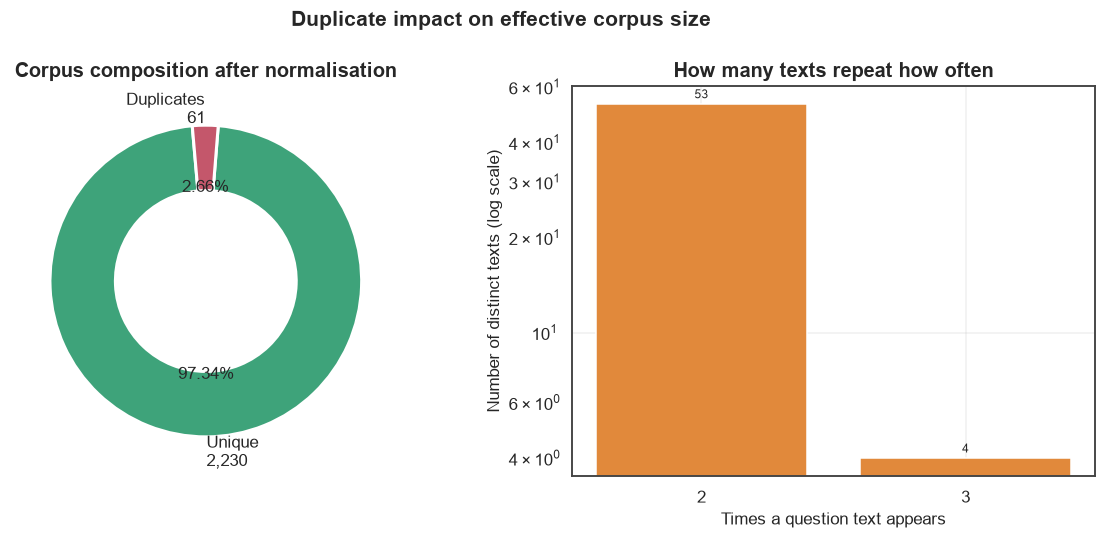

In [27]:
# ── Figure 2.8 — duplicate impact ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

sizes = [normalised.nunique(), exact_dupes]
labels = [f"Unique\n{sizes[0]:,}", f"Duplicates\n{sizes[1]:,}"]
axes[0].pie(sizes, labels=labels, autopct="%1.2f%%", startangle=95,
            colors=[PALETTE[2], PALETTE[3]],
            wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2))
axes[0].set_title("Corpus composition after normalisation")

if len(repeated):
    counts = repeated.value_counts().sort_index()
    bars = axes[1].bar(counts.index.astype(str), counts.values, color=PALETTE[1])
    axes[1].set_title("How many texts repeat how often")
    axes[1].set_xlabel("Times a question text appears")
    axes[1].set_ylabel("Number of distinct texts")
    axes[1].bar_label(bars, fmt="%d", padding=2, fontsize=8)
    axes[1].set_yscale("log")
    axes[1].set_ylabel("Number of distinct texts (log scale)")
else:
    axes[1].text(0.5, 0.5, "No repeated question texts", ha="center",
                 va="center", fontsize=12, transform=axes[1].transAxes)
    axes[1].set_axis_off()

fig.suptitle("Duplicate impact on effective corpus size", y=1.03,
             fontsize=14, fontweight="bold")
save_figure(fig, "duplicates",
            "Duplicates are removed in Stage 3 before splitting, so no question "
            "can appear in both the training and the test split.")
plt.show()

---

## Step 12 — Vocabulary and Zipf analysis

This step sizes the **tokenizer vocabulary** trained in Stage 5. The two things
that matter:

- **Coverage curve** — what fraction of all word occurrences the top *k* words
  account for. The vocabulary size is chosen at the knee of this curve.
- **Zipf plot** — log rank against log frequency. A straight line confirms the
  corpus behaves like natural language, which is the assumption byte-pair
  encoding relies on.

In [28]:
from collections import Counter

tokens = re.findall(r"[a-z0-9]+", " ".join(data["question"]).lower())
vocab = Counter(tokens)
frequencies = np.array(sorted(vocab.values(), reverse=True))
cumulative = np.cumsum(frequencies) / frequencies.sum() * 100

print("VOCABULARY STATISTICS")
print("=" * 62)
print(f"  Total tokens        : {len(tokens):,}")
print(f"  Distinct word types : {len(vocab):,}")
print(f"  Type-token ratio    : {len(vocab) / len(tokens):.4f}")
print(f"  Hapax legomena      : {sum(1 for c in vocab.values() if c == 1):,} "
      f"({sum(1 for c in vocab.values() if c == 1) / len(vocab) * 100:.1f}% "
      f"appear exactly once)")
print("=" * 62)
print("\n  Top 15 tokens:")
for word, count in vocab.most_common(15):
    print(f"    {word:18s} {count:6,}  ({count / len(tokens) * 100:5.2f}%)")

print("\n  Coverage by vocabulary size:")
for k in (500, 1000, 2000, 4000, 8000, 16000):
    if k <= len(frequencies):
        print(f"    top {k:6,} types -> {cumulative[k - 1]:6.2f}% of all tokens")

# The vocabulary size for Stage 5 is chosen where coverage crosses 99%.
TARGET_COVERAGE = 99.0
knee = int(np.searchsorted(cumulative, TARGET_COVERAGE) + 1)
RECOMMENDED_VOCAB = int(min(16000, max(4000, 2 ** np.ceil(np.log2(knee)))))
print(f"\n  {TARGET_COVERAGE}% token coverage needs {knee:,} word types.")
print(f"  Recommended BPE vocabulary for Stage 5: {RECOMMENDED_VOCAB:,} "
      f"(subword units generalise beyond whole words).")

VOCABULARY STATISTICS
  Total tokens        : 21,840
  Distinct word types : 2,889
  Type-token ratio    : 0.1323
  Hapax legomena      : 1,270 (44.0% appear exactly once)

  Top 15 tokens:
    what                1,150  ( 5.27%)
    is                    888  ( 4.07%)
    the                   877  ( 4.02%)
    a                     620  ( 2.84%)
    and                   598  ( 2.74%)
    you                   563  ( 2.58%)
    of                    519  ( 2.38%)
    how                   514  ( 2.35%)
    in                    482  ( 2.21%)
    are                   444  ( 2.03%)
    to                    391  ( 1.79%)
    do                    358  ( 1.64%)
    for                   231  ( 1.06%)
    an                    221  ( 1.01%)
    between               175  ( 0.80%)

  Coverage by vocabulary size:
    top    500 types ->  78.32% of all tokens
    top  1,000 types ->  87.87% of all tokens
    top  2,000 types ->  95.93% of all tokens

  99.0% token coverage needs 2,671 word

C:\Users\gihan\AppData\Local\Temp\ipykernel_35384\1390818676.py:40: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.savefig(path)


Figure 2.9: Left: coverage curve used to choose the vocabulary size. Right: the corpus follows Zipf's law, validating subword tokenisation.
           saved -> reports\figures\02_fig09_vocabulary_zipf.png


C:\Users\gihan\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


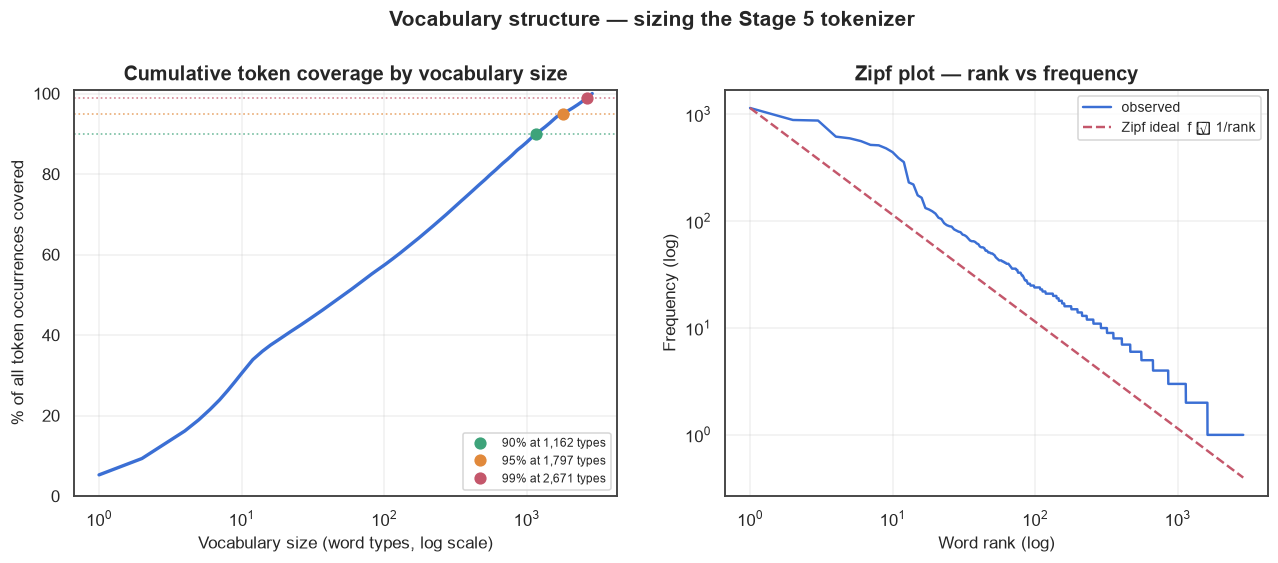

In [29]:
# ── Figure 2.9 — vocabulary coverage and Zipf's law ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(np.arange(1, len(cumulative) + 1), cumulative,
             linewidth=2.2, color=PALETTE[0])
for target, colour in [(90, PALETTE[2]), (95, PALETTE[1]), (99, PALETTE[3])]:
    k = int(np.searchsorted(cumulative, target) + 1)
    axes[0].axhline(target, color=colour, linestyle=":", linewidth=1.1, alpha=0.7)
    axes[0].plot([k], [target], "o", color=colour, markersize=7,
                 label=f"{target}% at {k:,} types")
axes[0].set_xscale("log")
axes[0].set_title("Cumulative token coverage by vocabulary size")
axes[0].set_xlabel("Vocabulary size (word types, log scale)")
axes[0].set_ylabel("% of all token occurrences covered")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_ylim(0, 101)

ranks = np.arange(1, len(frequencies) + 1)
axes[1].loglog(ranks, frequencies, linewidth=1.6, color=PALETTE[0],
               label="observed")
# Zipf's law predicts frequency proportional to 1/rank.
zipf = frequencies[0] / ranks
axes[1].loglog(ranks, zipf, linestyle="--", linewidth=1.6, color=PALETTE[3],
               label="Zipf ideal  f ∝ 1/rank")
axes[1].set_title("Zipf plot — rank vs frequency")
axes[1].set_xlabel("Word rank (log)")
axes[1].set_ylabel("Frequency (log)")
axes[1].legend(fontsize=9)

fig.suptitle("Vocabulary structure — sizing the Stage 5 tokenizer", y=1.03,
             fontsize=14, fontweight="bold")
save_figure(fig, "vocabulary_zipf",
            "Left: coverage curve used to choose the vocabulary size. Right: "
            "the corpus follows Zipf's law, validating subword tokenisation.")
plt.show()

---

## Step 13 — Outlier quantification

The final input to Stage 3. Outliers are counted by the **1.5 × IQR** rule, and
crucially the table reports *how much of the corpus each cut would remove* — so
the cleaning thresholds are chosen with their cost visible, not guessed.

In [30]:
outlier_rows = []
for col in [c for c in ["q_char_len", "q_word_count", "q_sentence_count",
                        "q_avg_word_len"] if c in data.columns]:
    series = pd.to_numeric(data[col], errors="coerce").dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    below = int((series < low).sum())
    above = int((series > high).sum())
    outlier_rows.append({
        "variable": col,
        "Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
        "lower_fence": round(low, 2), "upper_fence": round(high, 2),
        "below": below, "above": above,
        "outliers": below + above,
        "outlier_%": round((below + above) / len(series) * 100, 2),
    })

outliers = pd.DataFrame(outlier_rows)
print("IQR OUTLIER ANALYSIS (1.5 x IQR rule)")
print("=" * 108)
print(outliers.to_string(index=False))
print("=" * 108)

# The cleaning rule Stage 3 will apply, with its cost stated up front.
MIN_WORDS, MAX_WORDS = 4, int(np.percentile(data["q_word_count"].dropna(), 99))
MAX_SENTENCES = 2
too_short = int((data["q_word_count"] < MIN_WORDS).sum())
too_long = int((data["q_word_count"] > MAX_WORDS).sum())
multi_part = int((data["q_sentence_count"] > MAX_SENTENCES).sum())
has_code = int(data["q_has_code_marker"].sum())

print("\nPROPOSED STAGE 3 CLEANING RULE, AND ITS COST")
print("=" * 76)
print(f"  Remove questions under {MIN_WORDS} words          : "
      f"{too_short:6,}  ({too_short / len(data) * 100:5.2f}%)")
print(f"  Remove questions over {MAX_WORDS} words (p99)    : "
      f"{too_long:6,}  ({too_long / len(data) * 100:5.2f}%)")
print(f"  Remove multi-part (> {MAX_SENTENCES} sentences)         : "
      f"{multi_part:6,}  ({multi_part / len(data) * 100:5.2f}%)")
print(f"  Remove containing code punctuation      : "
      f"{has_code:6,}  ({has_code / len(data) * 100:5.2f}%)")
print(f"  Remove exact duplicates                 : "
      f"{exact_dupes:6,}  ({exact_dupes / len(data) * 100:5.2f}%)")

survives = data[
    (data["q_word_count"].between(MIN_WORDS, MAX_WORDS))
    & (data["q_sentence_count"] <= MAX_SENTENCES)
    & (data["q_has_code_marker"] == 0)
    & (~normalised.duplicated())
]
print("-" * 76)
print(f"  Estimated corpus after cleaning         : "
      f"{len(survives):6,}  ({len(survives) / len(data) * 100:5.2f}% retained)")
print("=" * 76)

IQR OUTLIER ANALYSIS (1.5 x IQR rule)
        variable    Q1   Q3   IQR  lower_fence  upper_fence  below  above  outliers  outlier_%
      q_char_len 34.00 64.0 30.00       -11.00       109.00      0    220       220       9.60
    q_word_count  6.00 11.0  5.00        -1.50        18.50      0    122       122       5.33
q_sentence_count  1.00  1.0  0.00         1.00         1.00      0    153       153       6.68
  q_avg_word_len  5.25  6.6  1.35         3.22         8.63      0     56        56       2.44

PROPOSED STAGE 3 CLEANING RULE, AND ITS COST
  Remove questions under 4 words          :     99  ( 4.32%)
  Remove questions over 33 words (p99)    :     23  ( 1.00%)
  Remove multi-part (> 2 sentences)         :     28  ( 1.22%)
  Remove containing code punctuation      :     40  ( 1.75%)
  Remove exact duplicates                 :     61  ( 2.66%)
----------------------------------------------------------------------------
  Estimated corpus after cleaning         :  2,060  (89.9

---

## Step 14 — Persist every statistic

Everything quoted above is written to `reports/eda_summary.json`, so Stage 3
reads its thresholds from this file rather than having them re-typed — which is
what keeps the notebooks consistent with each other.

In [31]:
eda_summary = {
    "stage": "02_exploratory_data_analysis",
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "corpus": {
        "rows": int(len(data)),
        "columns": int(data.shape[1]),
        "unique_questions": int(normalised.nunique()),
        "exact_duplicates": exact_dupes,
        "near_duplicate_pairs": len(near_dupe_pairs),
    },
    "numeric_summary": {
        col: describe_series(data[col], col).round(4).to_dict()
        for col in NUMERIC_COLS
    },
    "class_balance": balance_report,
    "correlation": {
        "strong_pairs": [
            {"a": r["a"], "b": r["b"], "r": round(float(r["r"]), 4)}
            for _, r in strong.iterrows()
        ],
        "label_leakage_detected": bool(len(leak)),
    },
    "vocabulary": {
        "total_tokens": len(tokens),
        "distinct_types": len(vocab),
        "hapax_count": int(sum(1 for c in vocab.values() if c == 1)),
        "types_for_99pc_coverage": int(knee),
        "recommended_bpe_vocab": int(RECOMMENDED_VOCAB),
    },
    "outliers": outliers.to_dict(orient="records"),
    # Stage 3 reads these thresholds directly.
    "cleaning_thresholds": {
        "min_words": int(MIN_WORDS),
        "max_words": int(MAX_WORDS),
        "max_sentences": int(MAX_SENTENCES),
        "reject_code_markers": True,
        "drop_exact_duplicates": True,
        "estimated_retained": int(len(survives)),
        "estimated_retention_pct": round(len(survives) / len(data) * 100, 2),
    },
}

summary_path = REPORTS_DIR / "eda_summary.json"
summary_path.write_text(json.dumps(eda_summary, indent=2, default=str),
                        encoding="utf-8")

figures = sorted(FIGURES_DIR.glob(f"{NOTEBOOK_ID:02d}_*.png"))
print(f"EDA summary written : {summary_path.relative_to(WORKSPACE_DIR)}")
print(f"Figures produced    : {len(figures)}")
for path in figures:
    print(f"  - {path.name}")

EDA summary written : reports\eda_summary.json
Figures produced    : 9
  - 02_fig01_missingness.png
  - 02_fig02_histograms.png
  - 02_fig03_box_ecdf.png
  - 02_fig04_class_balance.png
  - 02_fig05_length_by_class.png
  - 02_fig06_correlation_heatmap.png
  - 02_fig07_label_grid.png
  - 02_fig08_duplicates.png
  - 02_fig09_vocabulary_zipf.png


---

## Stage 2 summary — findings and the decisions they force

| # | Finding | Decision it forces in Stage 3 / 4 |
|---|---|---|
| 1 | Length variables are right-skewed and heavy-tailed (Fig 2.2, 2.3) | Cap length at the **99th percentile**, not mean ± sd |
| 2 | Whitespace-only fields exist alongside true nulls (Step 5) | Normalise blanks to null **before** imputation |
| 3 | Classes are imbalanced (Fig 2.4) | Use **stratified** splitting in Stage 4 |
| 4 | Question length does not separate difficulty (Step 8 ANOVA) | Difficulty must be learned from **wording**, never length |
| 5 | No feature predicts a label at \|r\| ≥ 0.5 (Fig 2.6) | No label leakage — accuracy figures are trustworthy |
| 6 | Some (domain, difficulty) cells are thin (Fig 2.7) | Runtime planner **widens** its search for thin cells |
| 7 | Duplicates and near-duplicates present (Fig 2.8) | Deduplicate **before** splitting, to prevent train/test overlap |
| 8 | 99% token coverage needs a few thousand types (Fig 2.9) | Train the BPE tokenizer at the recommended vocabulary size |
| 9 | Cleaning retains the share reported in Step 13 | Thresholds accepted with their cost known |

### Figures produced

| Figure | Content |
|---|---|
| 2.1 | Missing-data audit and missingness matrix |
| 2.2 | Histograms with KDE for every numeric variable |
| 2.3 | Box plots and empirical CDF |
| 2.4 | Class balance with imbalance ratios |
| 2.5 | Violin and box plots of length by class |
| 2.6 | Pearson correlation heatmap |
| 2.7 | Domain × difficulty coverage heatmap |
| 2.8 | Duplicate impact on effective corpus size |
| 2.9 | Vocabulary coverage curve and Zipf plot |

### Next

**Notebook 03 — Data Preprocessing**, which applies exactly the thresholds
recorded in `reports/eda_summary.json` and shows before/after distributions for
each one.